# cosine correction comparison

## read cosine corrected

In [4]:
import atmPy.radiation.retrievals.spectral_irradiance as atmsi

In [27]:
import atmPy.general.measurement_site as atmsite

In [104]:
plt.rcParams['figure.dpi'] = 200

/var/folders/f4/dl3whmyd1rj_9smbyhmyqyj1h26f40/T/ipykernel_21915/2308479431.py:7: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(fl[slice(i,i+2)])


15
2026-03-07 00:00:00


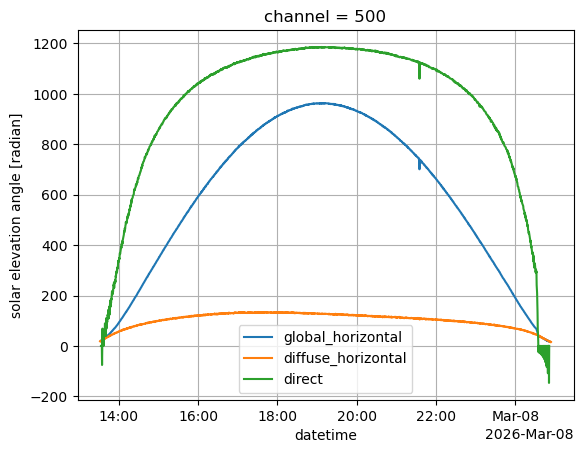

In [95]:
# i = -1
# i = 12 # 2026-03-04 strange spike
i += 1
p2fld = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/cosine_corrected/v0.1/2026/')
fl = list(p2fld.glob('*.nc'))
fl.sort()
ds = xr.open_mfdataset(fl[slice(i,i+2)])

site = atmsite.Station(lat = ds.site_latitude, lon = ds.site_longitude, name = ds.site_name)
tdiff = pd.to_timedelta(site.time_zone['diff2UTC_of_standard_time'], 'h')
dt_local = pd.DatetimeIndex(ds.datetime + tdiff)
start = dt_local[0].ceil("D")
end = start  + pd.to_timedelta(1, 'D') - pd.to_timedelta(1, 'ns')
assert(start.date() == end.date()), f'Start ({start}) and end ({end}) timestamps are on different days, this should not happen!?!'
ds = ds.sel(datetime = slice(start - tdiff, end - tdiff))
print(i)
print(start)

# ds = xr.open_dataset(p2f)
dscc = atmsi.CombinedGlobalDiffuseDirect(ds)
dscc.plot_overview()
None

In [86]:
import atmPy.data_archives.NOAA_ESRL_GMD_GRAD.surfrad.surfrad as atmsrf

In [96]:
# si_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/tu/2026/tbl_mfrsr_20260106_D824_3126_660.tu'), raisefilterfunctionerror=False)
si_tu = atmsrf.read_ccc(pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/tbl/mfrsr/tu/2026/tbl_mfrsr_20260307_D824_3126_660.tu'), raisefilterfunctionerror=False)

si_tu.dataset = si_tu.dataset.reindex(datetime = dscc.dataset.datetime, method='bfill')
si_tu.dataset = si_tu.dataset.rename({'direct_normal_irradiation': 'direct_normal', 'diffuse_horizontal_irradiation': 'diffuse_horizontal', 'global_horizontal_irradiation': 'global_horizontal'})

Text(0, 0.5, 'irradiance (mV)')

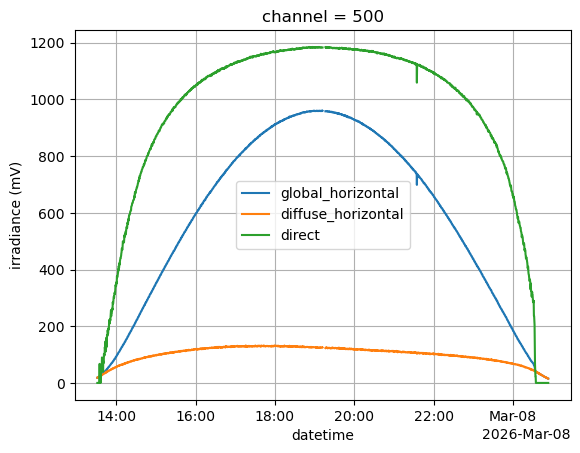

In [98]:
f,a = si_tu.plot_overview(channel=500)
a.set_ylabel('irradiance (mV)')

# Langleys

## am

In [132]:
amr = [2.2,5]

In [133]:
dscc.direct_normal_irradiation._am = None
dscc.direct_normal_irradiation._pm = None
dscc.direct_normal_irradiation.settings_langley_airmass_limits = amr

In [134]:
si_tu.direct_normal_irradiation._am = None
si_tu.direct_normal_irradiation._pm = None
si_tu.direct_normal_irradiation.settings_langley_airmass_limits = amr

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in log
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

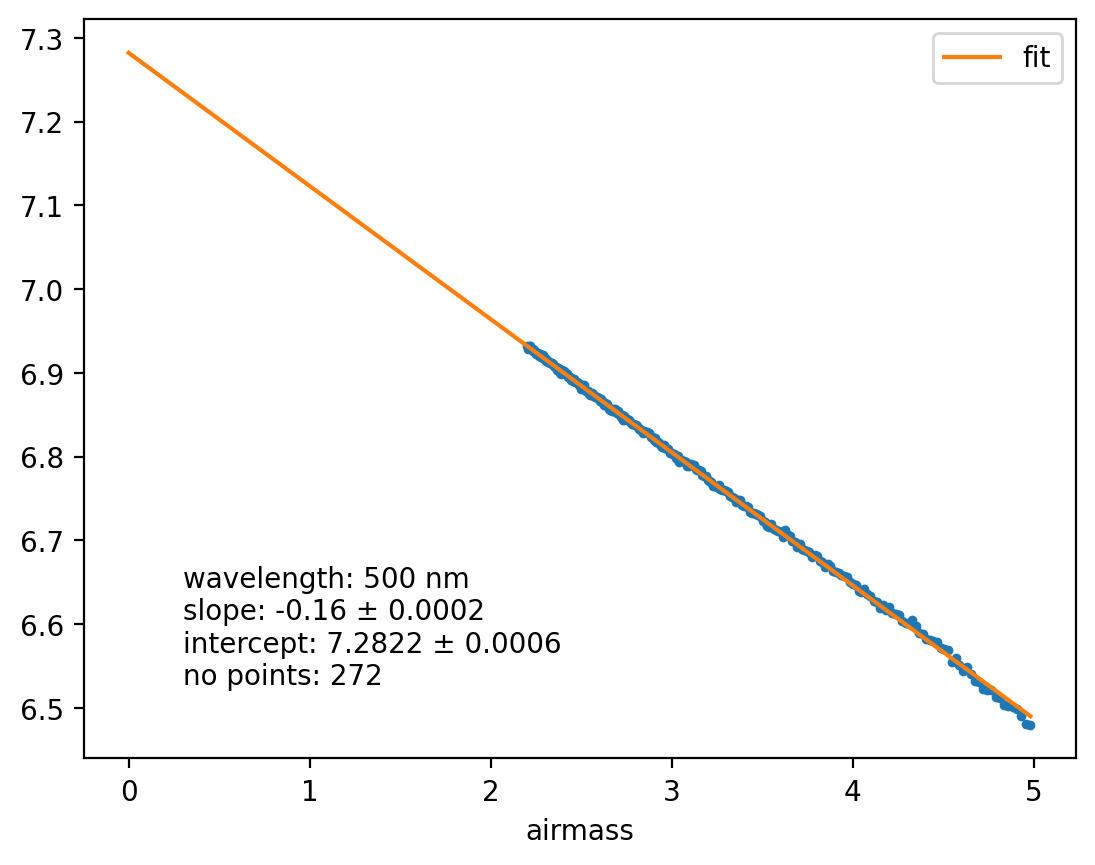

In [135]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=500, show_pre_clean=False)

/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

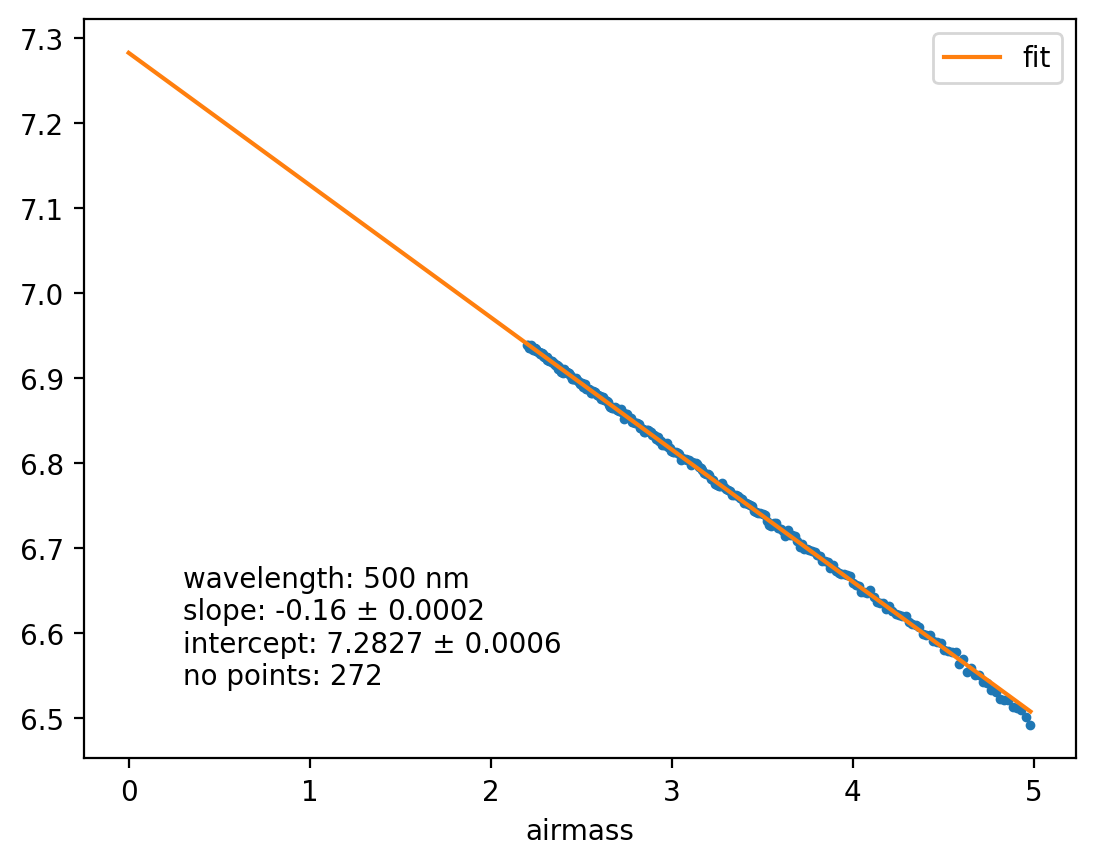

In [137]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

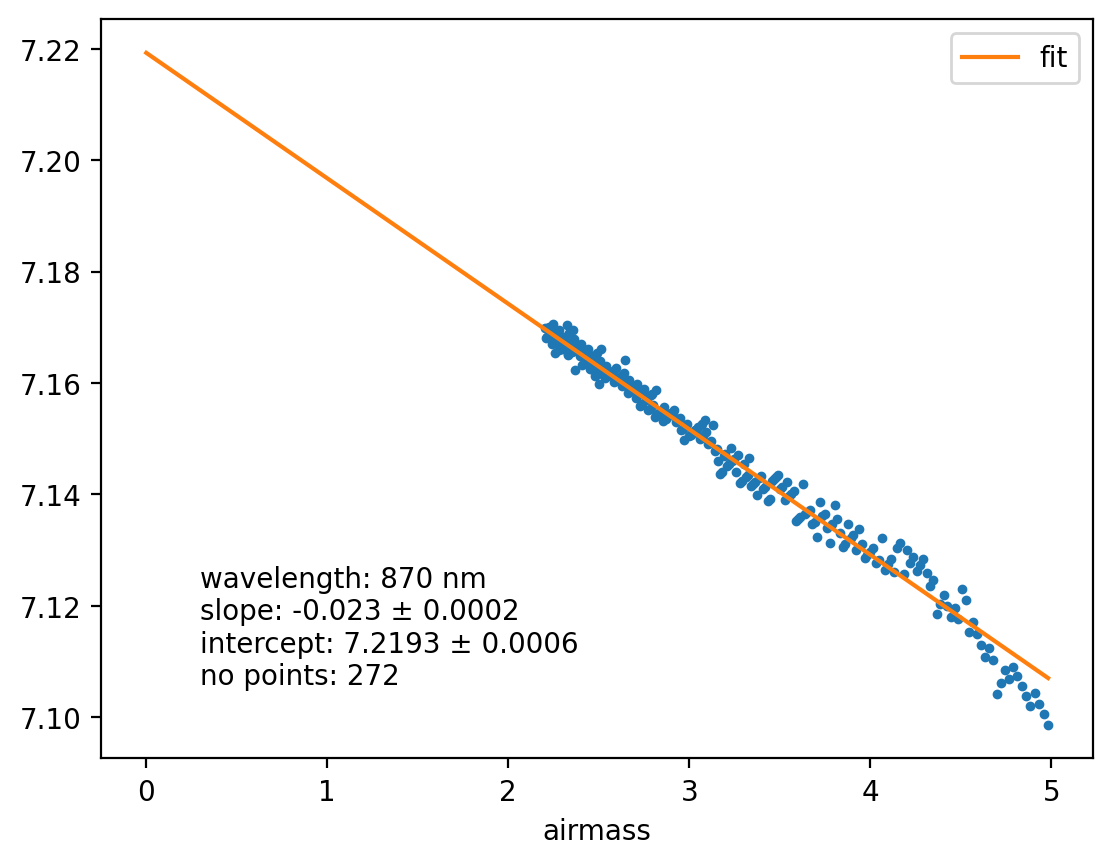

In [136]:
dscc.direct_normal_irradiation.langley_am.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

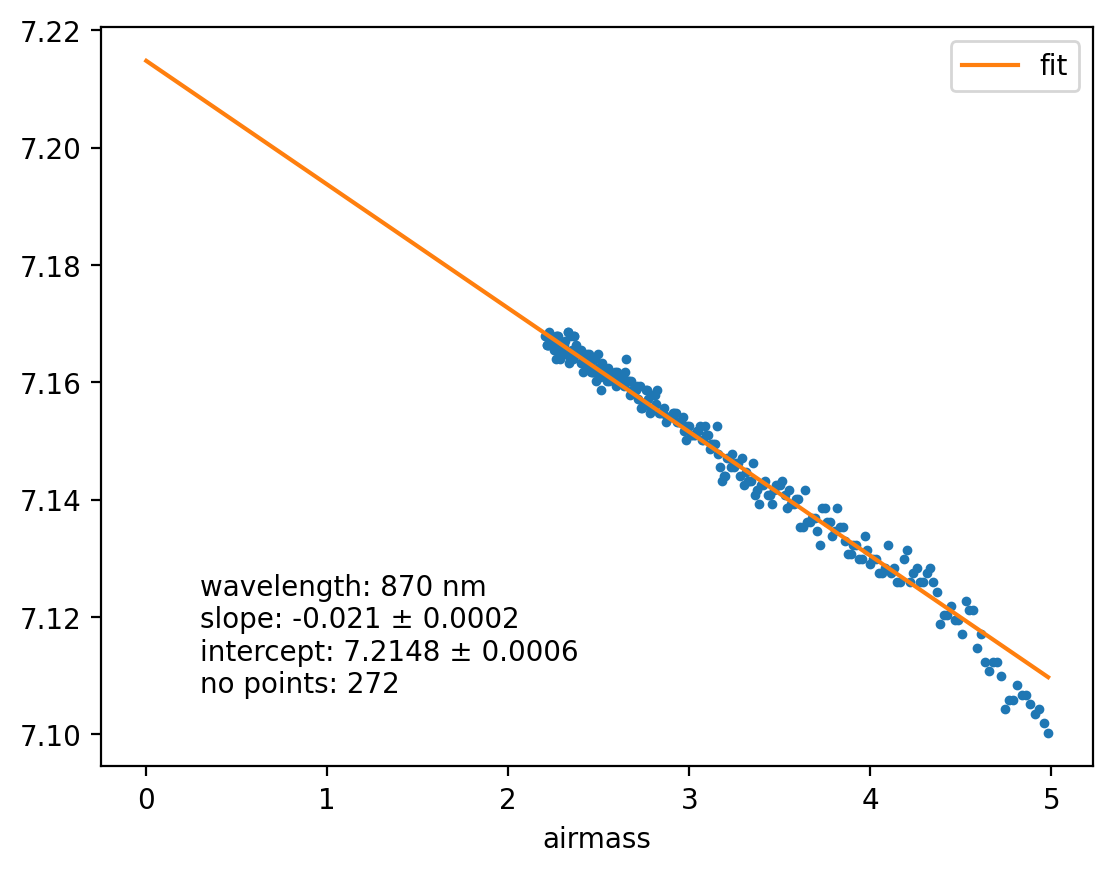

In [138]:
si_tu.direct_normal_irradiation.langley_am.plot(wavelength=870, show_pre_clean=False)

## pm

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

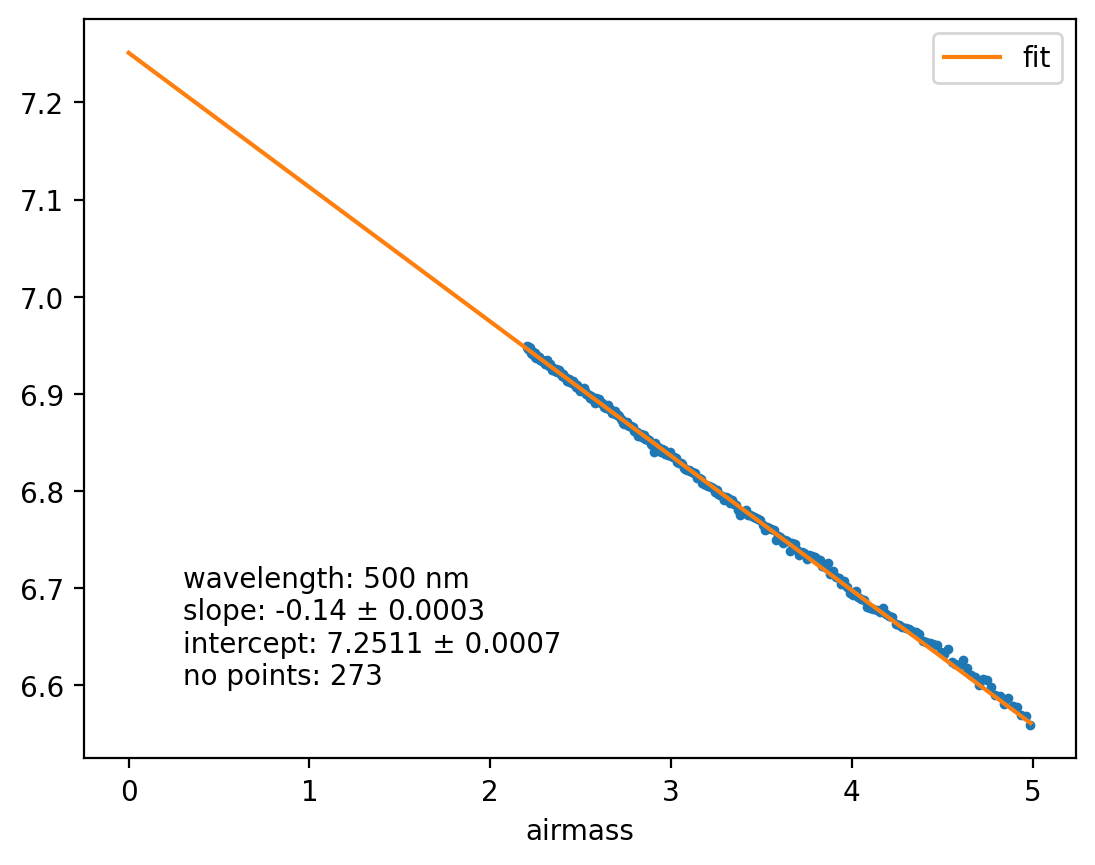

In [139]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

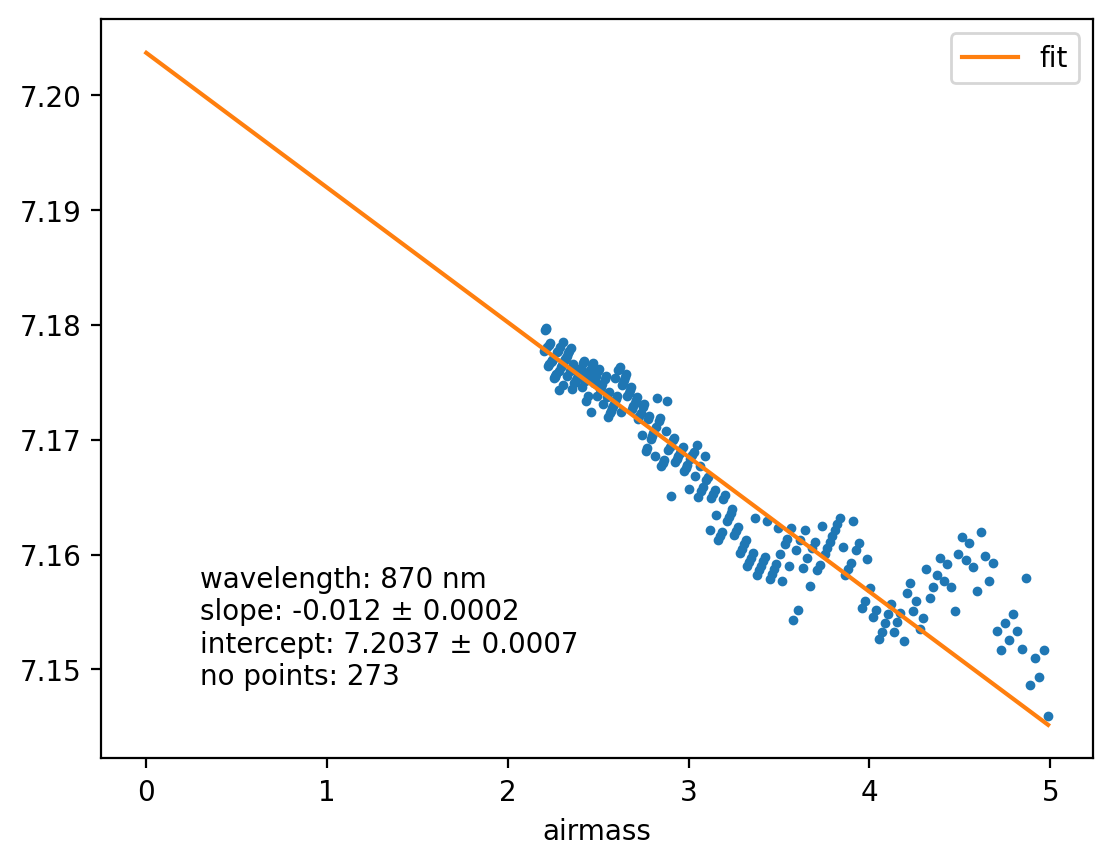

In [140]:
dscc.direct_normal_irradiation.langley_pm.plot(wavelength=870, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

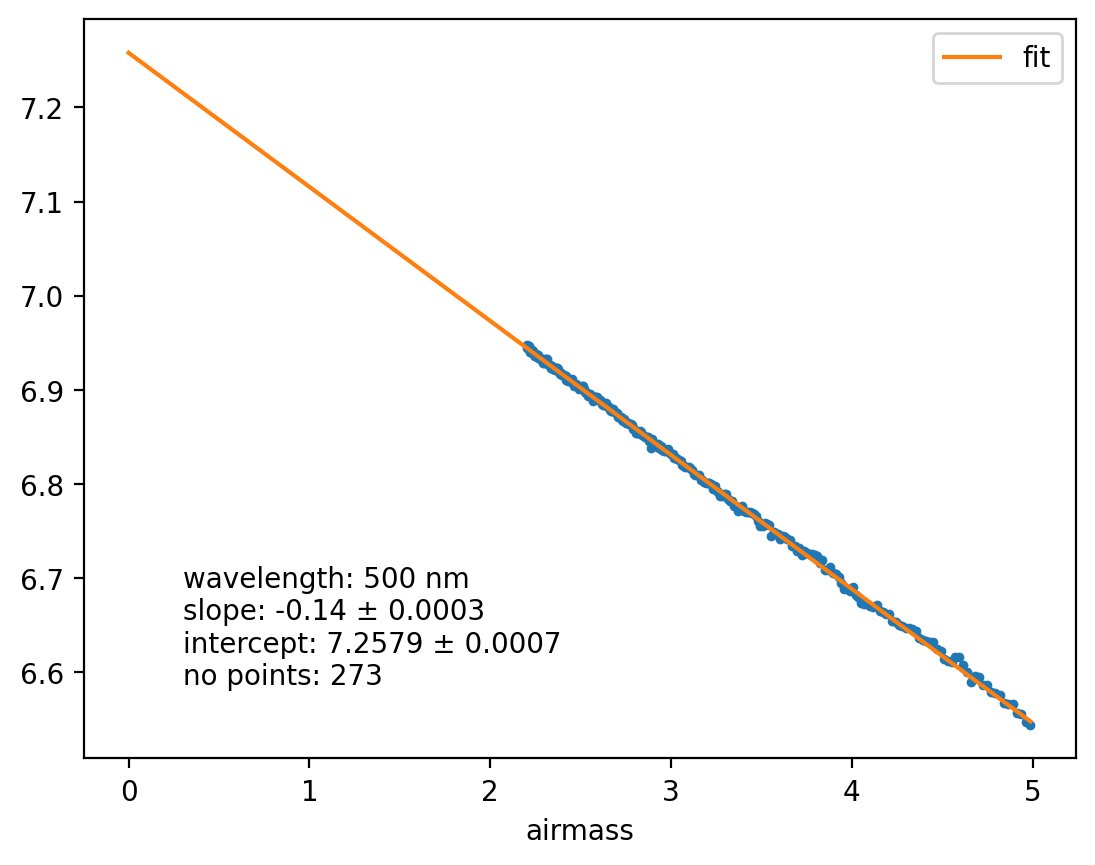

In [141]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=500, show_pre_clean=False)

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

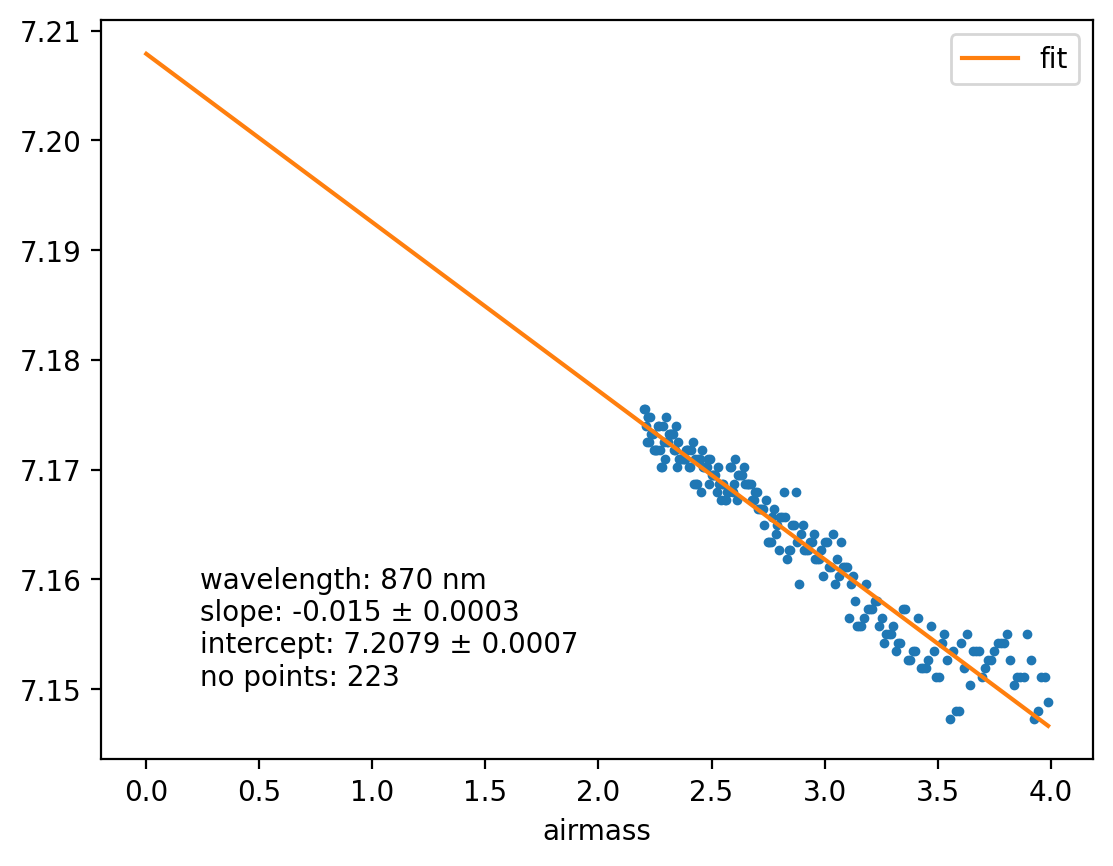

(<Figure size 1280x960 with 1 Axes>, <Axes: xlabel='airmass'>)

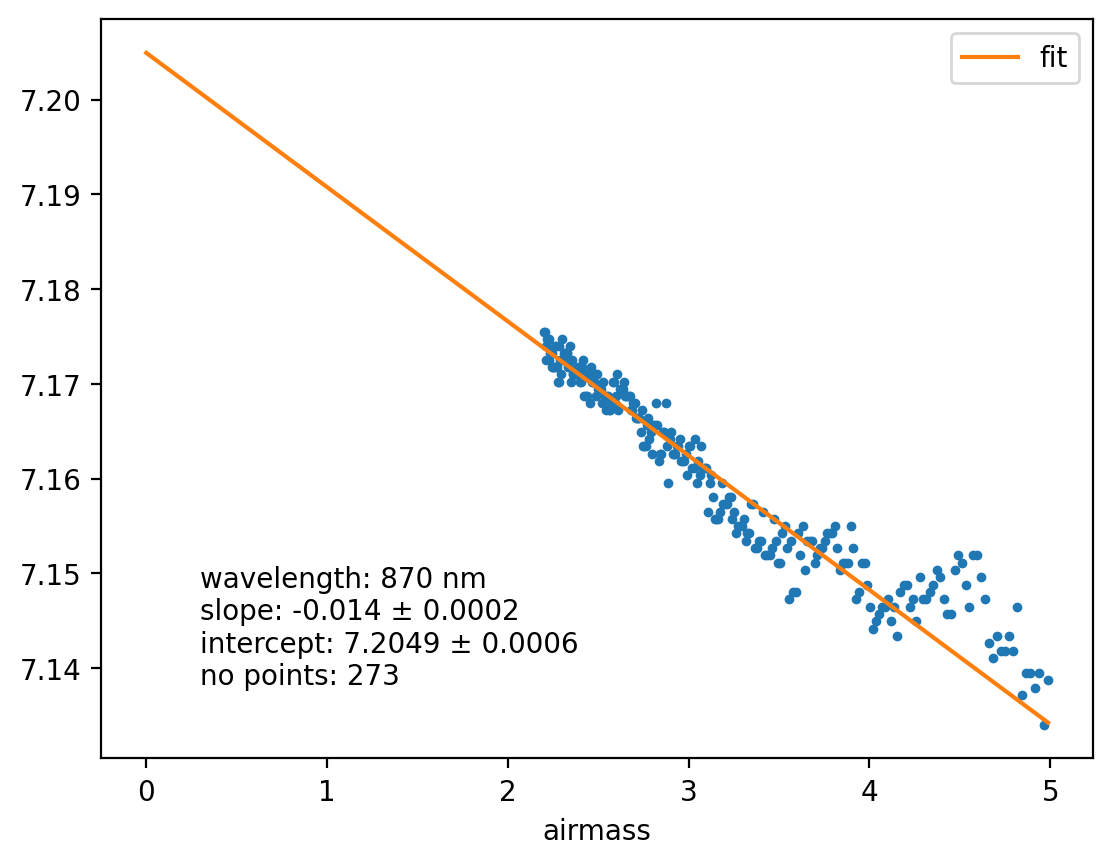

In [142]:
si_tu.direct_normal_irradiation.langley_pm.plot(wavelength=870, show_pre_clean=False)

In [148]:
df = pd.DataFrame()
df['dscc_am'] = dscc.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['tu_am'] = si_tu.direct_normal_irradiation.langley_am.langley_fitres.intercept
df['dscc_pm'] = dscc.direct_normal_irradiation.langley_pm.langley_fitres.intercept
df['tu_pm'] = si_tu.direct_normal_irradiation.langley_pm.langley_fitres.intercept

# df['tu_ratio'] = df.tu_am/df.tu_pm
# df['tu_dif'] = df.tu_am - df.tu_pm
# df['dscc_dif'] = df.dscc_am - df.dscc_pm

df['tu_dif'] = np.exp(df.tu_am) - np.exp(df.tu_pm)
df['dscc_dif'] = np.exp(df.dscc_am) - np.exp(df.dscc_pm)

df['tu_uc'] = df.tu_dif / np.exp(df.tu_am)
df['dscc_uc'] = df.dscc_dif / np.exp(df.dscc_am)

df['tuVSdscc'] = abs(((np.exp(df['dscc_am']) + np.exp(df['dscc_pm']))/2) - ((np.exp(df['tu_am']) + np.exp(df['tu_pm']))/2))
df['tuVSdscc_rel'] = df.tuVSdscc / np.exp((df['dscc_am'] + df['dscc_pm'])/2)

df

,dscc_am,tu_am,dscc_pm,tu_pm,tu_dif,dscc_dif,tu_uc,dscc_uc,tuVSdscc,tuVSdscc_rel
wavelength,,,,,,,,,,
415,7.448090,7.450867,7.416574,7.430771,34.247061,53.256543,0.019895,0.031025,14.277869,0.008450
500,7.282233,7.282729,7.251109,7.257931,35.636683,44.564581,0.024493,0.030645,5.185593,0.003622
670,6.973465,6.972575,6.953729,6.959136,14.243288,20.869536,0.013349,0.019542,2.362925,0.002235
870,7.219270,7.214790,7.203656,7.204945,13.318355,21.154399,0.009797,0.015492,2.184531,0.001612
940,7.526996,7.520002,7.484440,7.484695,63.988538,77.390369,0.034690,0.041663,6.246775,0.003435
1625,6.270524,6.260144,6.247810,6.246258,7.216431,11.874415,0.013790,0.022457,3.130773,0.005989
